In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Support running either from this directory or from the repository root.
benchmark_dir = Path.cwd()
if not (benchmark_dir / 'experiment_1_natural_datasets.csv').is_file():
    benchmark_dir = benchmark_dir / 'benchmarking'

natural_datasets = pd.read_csv(benchmark_dir / 'experiment_1_natural_datasets.csv')
synthetic_datasets = pd.read_csv(benchmark_dir / 'experiment_2_subsampled_annotators.csv')

# Use synthetic datasets by default for plotting
df = synthetic_datasets.copy()

# Get full MSP Podcast data for dataset-level comparisons
full_msp_natural = natural_datasets[natural_datasets['config_name'] == 'full'].copy()

print(f"Synthetic dataset rows: {len(df)}")
print(f"Full MSP Podcast rows: {len(full_msp_natural)}")
print(f"\nModel types: {df['model_type'].unique()}")
print(f"\nCollator types: {df['collator_type'].unique()}")

Synthetic dataset rows: 3600
Full MSP Podcast rows: 600

Model types: ['BASELINE_AGGREGATE' 'INDIVIDUAL_ANNOTATOR' 'INDIVIDUAL_ANNOTATOR_LOOP']

Collator types: ['without_mapper' 'with_mapper']


In [3]:
# Filter for the three model configurations we want to compare (synthetic data)
baseline_df = df[(df['model_type'] == 'BASELINE_AGGREGATE') & (df['collator_type'] == 'without_mapper')].copy()
individual_df = df[(df['model_type'] == 'INDIVIDUAL_ANNOTATOR') & (df['collator_type'] == 'with_mapper')].copy()
individual_loop_df = df[(df['model_type'] == 'INDIVIDUAL_ANNOTATOR_LOOP') & (df['collator_type'] == 'with_mapper')].copy()

# Also filter full MSP Podcast data
baseline_msp = full_msp_natural[(full_msp_natural['model_type'] == 'BASELINE_AGGREGATE') & 
                                 (full_msp_natural['collator_type'] == 'without_mapper')].copy()
individual_msp = full_msp_natural[(full_msp_natural['model_type'] == 'INDIVIDUAL_ANNOTATOR') & 
                                   (full_msp_natural['collator_type'] == 'with_mapper')].copy()
individual_loop_msp = full_msp_natural[(full_msp_natural['model_type'] == 'INDIVIDUAL_ANNOTATOR_LOOP') & 
                                        (full_msp_natural['collator_type'] == 'with_mapper')].copy()

print(f"Synthetic Data:")
print(f"  Baseline (aggregate without mapper): {len(baseline_df)} rows")
print(f"  Individual annotator with mapper: {len(individual_df)} rows")
print(f"  Individual annotator loop with mapper: {len(individual_loop_df)} rows")
print(f"\nFull MSP Podcast:")
print(f"  Baseline (aggregate without mapper): {len(baseline_msp)} rows")
print(f"  Individual annotator with mapper: {len(individual_msp)} rows")
print(f"  Individual annotator loop with mapper: {len(individual_loop_msp)} rows")

Synthetic Data:
  Baseline (aggregate without mapper): 1200 rows
  Individual annotator with mapper: 1200 rows
  Individual annotator loop with mapper: 1200 rows

Full MSP Podcast:
  Baseline (aggregate without mapper): 200 rows
  Individual annotator with mapper: 200 rows
  Individual annotator loop with mapper: 200 rows


In [93]:
LEGEND_FONT = 32
AXIS_FONT = 23
def plot_comparison(y_metric, ylabel):
    """
    Create comparison plots for the three model types.
    Left: Aggregated line plot by dataset_total_annotators (with mean and std)
    Right: Raw scatter plot by total_annotators (batch-level)
    
    Parameters:
    - y_metric: Column name for y-axis (e.g., 'forward_time_ms', 'forward_memory_peak_mb')
    - ylabel: Label for y-axis
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    
    # Left plot: Aggregated line plot with groupby on dataset_total_annotators
    # Synthetic data
    if len(baseline_df) > 0:
        grouped = baseline_df.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='o', linestyle='-', label='_nolegend_', 
                color='blue', linewidth=3.5, markersize=12)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='blue', alpha=0.2, label='_nolegend_')
    
    if len(individual_df) > 0:
        grouped = individual_df.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='o', linestyle='-', label='_nolegend_', 
                color='orange', linewidth=3.5, markersize=12)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='orange', alpha=0.2, label='_nolegend_')
    
    if len(individual_loop_df) > 0:
        grouped = individual_loop_df.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='o', linestyle='-', label='_nolegend_', 
                color='green', linewidth=3.5, markersize=12)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='green', alpha=0.2, label='_nolegend_')
    
    # Natural data (Full MSP Podcast)
    if len(baseline_msp) > 0:
        grouped = baseline_msp.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='*', linestyle='--', label='_nolegend_', 
                color='blue', linewidth=3.5, markersize=18, zorder=5)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='blue', alpha=0.15, zorder=4, label='_nolegend_')
    
    if len(individual_msp) > 0:
        grouped = individual_msp.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='*', linestyle='--', label='_nolegend_', 
                color='orange', linewidth=3.5, markersize=18, zorder=5)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='orange', alpha=0.15, zorder=4, label='_nolegend_')
    
    if len(individual_loop_msp) > 0:
        grouped = individual_loop_msp.groupby('dataset_total_annotators')[y_metric].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('dataset_total_annotators')
        ax1.plot(grouped['dataset_total_annotators'], grouped['mean'], 
                marker='*', linestyle='--', label='_nolegend_', 
                color='green', linewidth=3.5, markersize=18, zorder=5)
        ax1.fill_between(grouped['dataset_total_annotators'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color='green', alpha=0.15, zorder=4, label='_nolegend_')
    
    ax1.set_xlabel('Dataset Total Annotators', fontsize=28, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=AXIS_FONT)
    
    # Right plot: Batch-level scatter plot (synthetic data only, no aggregation)
    if len(baseline_df) > 0:
        ax2.scatter(baseline_df['total_annotators'], baseline_df[y_metric], 
                   alpha=0.4, s=40, label='_nolegend_', color='blue')
    
    if len(individual_df) > 0:
        ax2.scatter(individual_df['total_annotators'], individual_df[y_metric], 
                   alpha=0.4, s=40, label='_nolegend_', color='orange')
    
    if len(individual_loop_df) > 0:
        ax2.scatter(individual_loop_df['total_annotators'], individual_loop_df[y_metric], 
                   alpha=0.4, s=40, label='_nolegend_', color='green')
    
    ax2.set_xlabel('Total Annotators (Batch-level)', fontsize=28, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=AXIS_FONT)
    
    # Shared y-axis label
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', 
             fontsize=28, fontweight='bold')
    
    # Create custom legend for the entire figure
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', linewidth=3.5, label='Consensus Model'),
        Line2D([0], [0], color='orange', linewidth=3.5, label='IA Model (ours)'),
        Line2D([0], [0], color='green', linewidth=3.5, label='IA Model (with loops)'),
        Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=12, label='Synthetic Data'),
        Line2D([0], [0], marker='*', color='gray', linestyle='None', markersize=18, label='Full MSP-Podcast')
    ]
#     legend_elements_col = [
#         Line2D([0], [0], color='blue', linewidth=3.5, label='Consensus Model'),
#         Line2D([0], [0], color='orange', linewidth=3.5, label='IA Model (ours)'),
#         Line2D([0], [0], color='green', linewidth=3.5, label='IA Model (with loops)'),
#     ]
#     legend_elements_sym = [
#         Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=12, label='Synthetic Data'),
#         Line2D([0], [0], marker='*', color='gray', linestyle='None', markersize=18, label='Full MSP-Podcast')
#     ]

    
#     fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
        #        ncol=5, fontsize=LEGEND_FONT, framealpha=0.9)
    
    # Alternate top left 
#     fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.4, 1.02), 
        #     ncol=2, fontsize=LEGEND_FONT, framealpha=0.9)
#     fig.legend(handles=legend_elements_col, loc='upper center', bbox_to_anchor=(0.706, 1.02), 
#             ncol=1, fontsize=LEGEND_FONT, framealpha=0.9)
#     fig.legend(handles=legend_elements_sym, loc='upper center', bbox_to_anchor=(0.208, 1.02), 
#             ncol=1, fontsize=LEGEND_FONT, framealpha=0.9)
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.52, -0.25), 
            ncol=3, fontsize=LEGEND_FONT, framealpha=0.9)
    

    plt.tight_layout(rect=[0.05, 0, 1, 0.92])  # Leave space for shared y-label and legend
    
    # Save as PDF
    filename = benchmark_dir / f"{y_metric}_comparison.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {filename}")
    
    plt.show()





## Performance Comparisons

Comparing forward time and memory usage at dataset-level and batch-level.

Saved plot to forward_time_ms_comparison.pdf


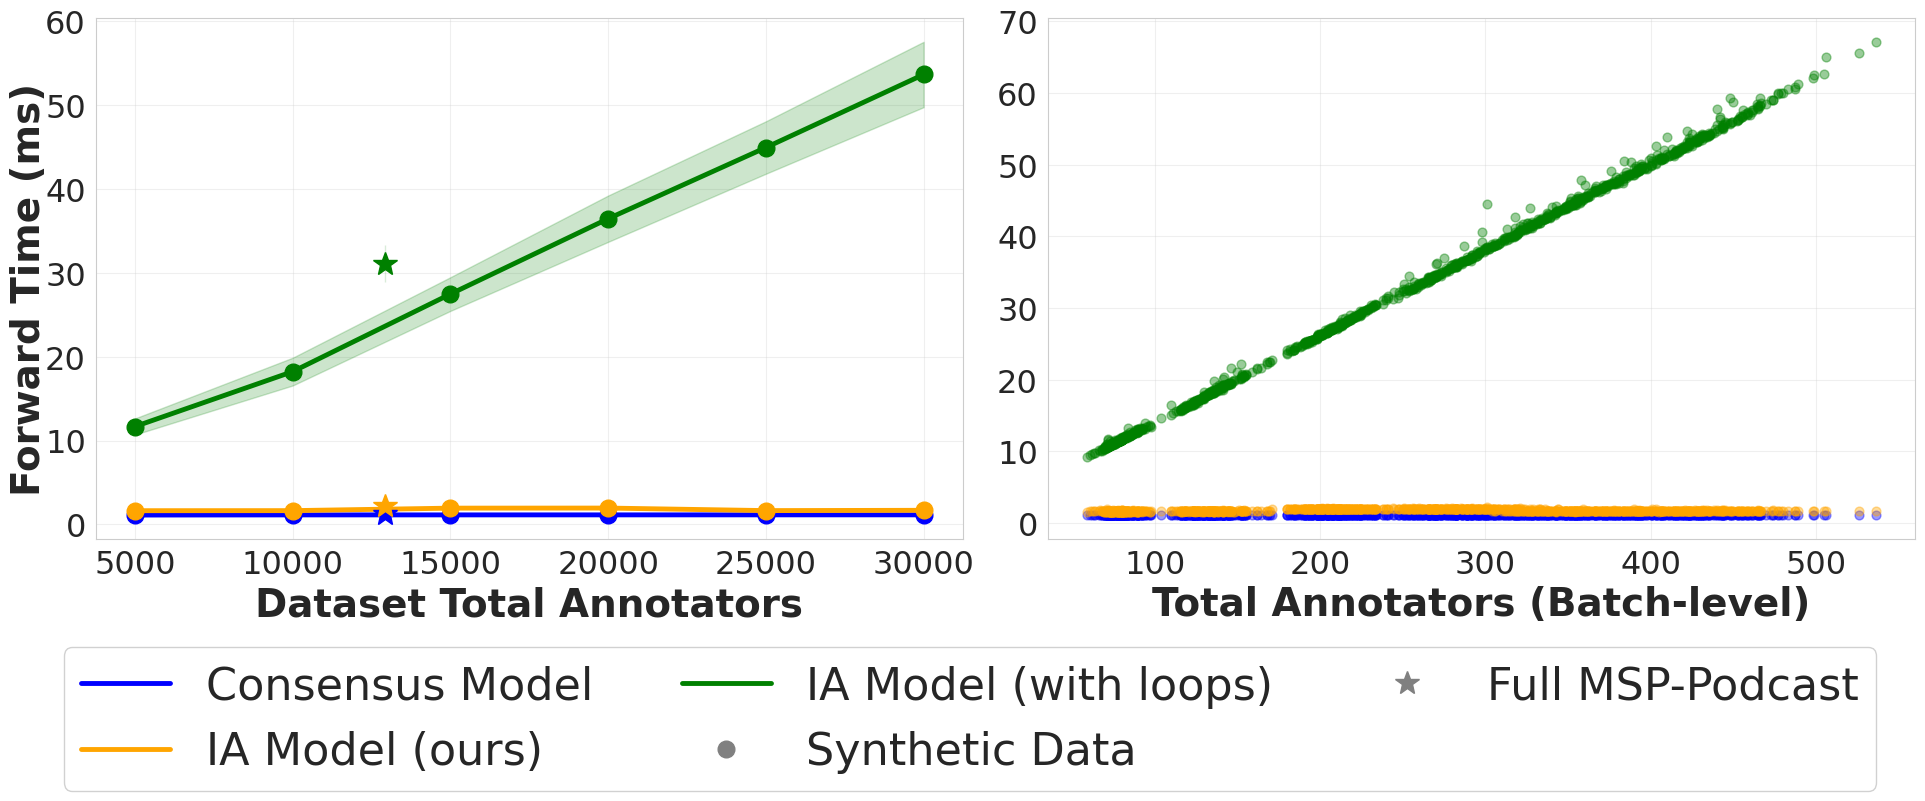

In [94]:
# Forward Time Comparison
plot_comparison('forward_time_ms', 'Forward Time (ms)')

Saved plot to forward_memory_peak_mb_comparison.pdf


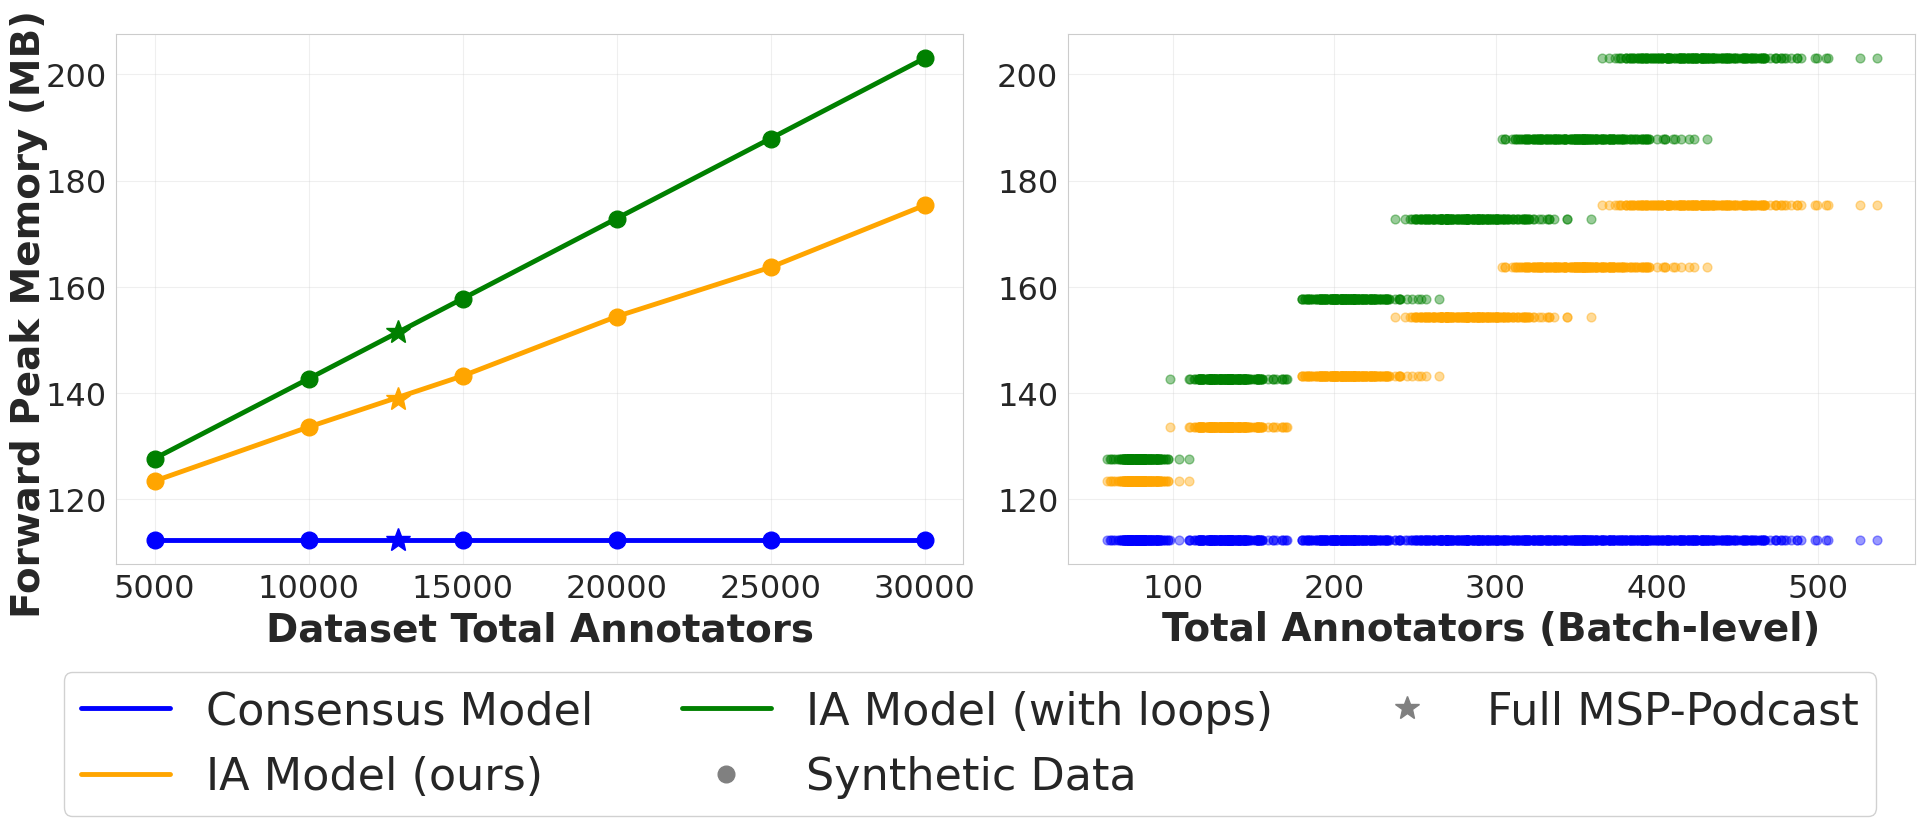

In [95]:
# Forward Peak Memory Comparison
plot_comparison('forward_memory_peak_mb', 'Forward Peak Memory (MB)')

## Collation Time Statistics

Collation time appears to be relatively constant regardless of batch/dataset size. Here are the overall statistics:

In [50]:
# Collation Time Statistics
print("=" * 80)
print("COLLATION TIME (ms) STATISTICS - SYNTHETIC DATA")
print("=" * 80)

print("\nBaseline Aggregate (without mapper):")
print(f"  Mean: {baseline_df['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {baseline_df['collation_time_ms'].std():.4f} ms")
print(f"  Min:  {baseline_df['collation_time_ms'].min():.4f} ms")
print(f"  Max:  {baseline_df['collation_time_ms'].max():.4f} ms")

print("\nIndividual Annotator (with mapper):")
print(f"  Mean: {individual_df['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {individual_df['collation_time_ms'].std():.4f} ms")
print(f"  Min:  {individual_df['collation_time_ms'].min():.4f} ms")
print(f"  Max:  {individual_df['collation_time_ms'].max():.4f} ms")

print("\nIndividual Annotator Loop (with mapper):")
print(f"  Mean: {individual_loop_df['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {individual_loop_df['collation_time_ms'].std():.4f} ms")
print(f"  Min:  {individual_loop_df['collation_time_ms'].min():.4f} ms")
print(f"  Max:  {individual_loop_df['collation_time_ms'].max():.4f} ms")

print("\n" + "=" * 80)
print("COLLATION TIME (ms) STATISTICS - FULL MSP PODCAST")
print("=" * 80)

print("\nBaseline Aggregate (without mapper):")
print(f"  Mean: {baseline_msp['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {baseline_msp['collation_time_ms'].std():.4f} ms")

print("\nIndividual Annotator (with mapper):")
print(f"  Mean: {individual_msp['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {individual_msp['collation_time_ms'].std():.4f} ms")

print("\nIndividual Annotator Loop (with mapper):")
print(f"  Mean: {individual_loop_msp['collation_time_ms'].mean():.4f} ms")
print(f"  Std:  {individual_loop_msp['collation_time_ms'].std():.4f} ms")

print("\n" + "=" * 80)
print("RELATIVE COMPARISON")
print("=" * 80)

baseline_mean = baseline_df['collation_time_ms'].mean()
individual_mean = individual_df['collation_time_ms'].mean()
loop_mean = individual_loop_df['collation_time_ms'].mean()

print(f"\nIndividual Annotator overhead vs Baseline: {((individual_mean - baseline_mean) / baseline_mean * 100):.1f}%")
print(f"Individual Annotator Loop overhead vs Baseline: {((loop_mean - baseline_mean) / baseline_mean * 100):.1f}%")
print(f"Individual Annotator Loop overhead vs Individual Annotator: {((loop_mean - individual_mean) / individual_mean * 100):.1f}%")

COLLATION TIME (ms) STATISTICS - SYNTHETIC DATA

Baseline Aggregate (without mapper):
  Mean: 1.3870 ms
  Std:  0.1213 ms
  Min:  1.2606 ms
  Max:  1.9928 ms

Individual Annotator (with mapper):
  Mean: 2.9696 ms
  Std:  0.1602 ms
  Min:  2.7093 ms
  Max:  3.6904 ms

Individual Annotator Loop (with mapper):
  Mean: 2.9888 ms
  Std:  0.2645 ms
  Min:  2.6994 ms
  Max:  9.2878 ms

COLLATION TIME (ms) STATISTICS - FULL MSP PODCAST

Baseline Aggregate (without mapper):
  Mean: 1.7559 ms
  Std:  0.0943 ms

Individual Annotator (with mapper):
  Mean: 3.8810 ms
  Std:  0.1024 ms

Individual Annotator Loop (with mapper):
  Mean: 3.9447 ms
  Std:  0.1042 ms

RELATIVE COMPARISON

Individual Annotator overhead vs Baseline: 114.1%
Individual Annotator Loop overhead vs Baseline: 115.5%
Individual Annotator Loop overhead vs Individual Annotator: 0.6%
